# Projet Science des Données – Prédiction du taux de réussite au brevet

## Sommaire

- [1. Pré-traitement des données](#pretraitement)
- [2. Visualisation des données](#visualisation)
- [3. Modèles de Machine Learning](#ml)
  - [3.1 Random Forest](#rf)
  - [3.2 Random Forest 2](#rf)
  - [3.3 GradientBoosting](#gb)
- [4. Évaluation et comparaison](#evaluation)
- [5. Conclusion](#conclusion)

## 1. Pré-traitement des données <a id="pretraitement"></a>


In [5]:
# Importation des bibliothèques nécessaires
import pandas as pd
import re

# Chargement des fichiers CSV hébergés sur GitHub (au format : CSV avec séparateur point-virgule)
fichier1 = "https://raw.githubusercontent.com/matyldaTricoire/Projet_Datascience/refs/heads/main/data/fr-en-college-effectifs-niveau-sexe-lv.csv"
fichier2 = "https://raw.githubusercontent.com/matyldaTricoire/Projet_Datascience/refs/heads/main/data/fr-en-dnb-par-etablissement-2.csv"

# Chargement des 2 jeux de données dans des DataFrames pandas
effectifs_colleges = pd.read_csv(fichier1, encoding='utf-8', sep=';', engine='python')
reussite_brevet = pd.read_csv(fichier2, encoding='utf-8', sep=';', engine='python')

# Affichage d’un aperçu des données
print(effectifs_colleges.head())
print(reussite_brevet.head())

# Filtrage : on conserve uniquement les années utiles à l'étude (2019, 2020, 2021)
# Méthode .isin() de pandas : filtrage par inclusion dans une liste
effectifs_colleges = effectifs_colleges[effectifs_colleges['Rentrée scolaire'].isin([2019, 2020, 2021])]
reussite_brevet = reussite_brevet[reussite_brevet['Session'].isin([2019, 2020, 2021])]
print("Premier fichier filtré :")
print(effectifs_colleges.head())
print("Deuxième fichier filtré :")
print(reussite_brevet.head())

# Nettoyage des identifiants : suppression des espaces en trop pour assurer la future fusion
# Utilisation de StackOverflow pour comprendre l’utilisation de .str.strip() :
# https://stackoverflow.com/questions/3739909/how-to-strip-all-spaces-in-a-string-in-python
effectifs_colleges.loc[:, "UAI"] = effectifs_colleges["UAI"].astype(str).str.strip()
reussite_brevet.loc[:, "Numero d'etablissement"] = reussite_brevet["Numero d'etablissement"].astype(str).str.strip()

# Vérification du nombre d'identifiants uniques dans chaque base
print("Valeurs uniques dans effectifs_colleges:", effectifs_colleges["UAI"].nunique())
print("Valeurs uniques dans réussite_brevet:", reussite_brevet["Numero d'etablissement"].nunique())

# Définition d'une fonction pour vérifier le format UAI
# Utilisation de la bibliothèque regex (recommandée par Chatgpt)
def check_format(series):
    """
    Vérifie si les identifiants respectent le format UAI standard : 7 chiffres + 1 lettre majuscule.
    Regex validée avec l’aide de ChatGPT pour gagner du temps.
    """
    return series.apply(lambda x: bool(re.match(r'^\d{7}[A-Z]$', str(x))))

set_effectifs = set(effectifs_colleges["UAI"])
set_reussite = set(reussite_brevet["Numero d'etablissement"])

# Suppression des doublons d’identifiants
effectifs_colleges = effectifs_colleges.drop_duplicates(subset=["UAI"])
reussite_brevet = reussite_brevet.drop_duplicates(subset=["Numero d'etablissement"])

# Vérification des doublons s'il y en reste
print("Doublons effectifs-college",effectifs_colleges["UAI"].value_counts().head(10))
print("Doublons réussite Brevet",reussite_brevet["Numero d'etablissement"].value_counts().head(10))

# Suppression des lignes contenant "GROUPE"
# Utilisation de .str.contains() avec l’argument na=False pour éviter les erreurs sur les valeurs nulles
reussite_brevet = reussite_brevet[~reussite_brevet["Numero d'etablissement"].str.contains("GROUPE", na=False)]

# Contrôle des identifiants non conformes au format dans UAI
non_conformes_UAI = len(effectifs_colleges["UAI"][~check_format(effectifs_colleges["UAI"])])
print(f"Nombre de valeurs non conformes dans 'UAI' (effectifs_colleges) : {non_conformes_UAI}")
non_conformes_reussite = len(reussite_brevet["Numero d'etablissement"][~check_format(reussite_brevet["Numero d'etablissement"])])
print(f"Nombre de valeurs non conformes dans 'Numero d'établissement' (reussite_brevet) : {non_conformes_reussite}")

# Mise à jour des ensembles après nettoyage
set_effectifs = set(effectifs_colleges["UAI"])
set_reussite = set(reussite_brevet["Numero d'etablissement"])

# Évaluation de l’intersection des établissements présents dans les deux fichiers
nombre_communs = len(set_effectifs.intersection(set_reussite))
print(f"Nombre d'établissements en commun : {nombre_communs}")

# Détection des identifiants manquants dans chaque base
UAI_manquants = len(set_effectifs - set_reussite)
print(f"Nombre d'UAI manquants dans 'reussite_brevet' : {UAI_manquants}")
numero_manquants = len(set_reussite - set_effectifs)
print(f"Nombre de Numéro d'établissement manquants dans 'effectifs_colleges' : {numero_manquants}")

# Filtrage des DataFrames pour ne garder que les établissements communs
valeurs_communes = set_effectifs.intersection(set_reussite)
effectifs_colleges = effectifs_colleges[effectifs_colleges["UAI"].isin(valeurs_communes)]
reussite_brevet = reussite_brevet[reussite_brevet["Numero d'etablissement"].isin(valeurs_communes)]
print(f"Nouvelle taille de effectifs_colleges : {effectifs_colleges.shape}")
print(f"Nouvelle taille de réussite_brevet : {reussite_brevet.shape}")
print(f"Nombre d'établissements en commun après filtrage : {len(set(effectifs_colleges['UAI']))}")

# Fusion des deux bases de données sur la clé commune UAI / Numéro d’établissement
df_final = effectifs_colleges.merge(reussite_brevet, left_on="UAI", right_on="Numero d'etablissement", how="inner")
print(df_final.shape)

# Renommage des colonnes pour les rendre plus lisibles et cohérentes pour la suite de l’analyse
df_final = df_final.rename(columns={
    "Rentrée scolaire": "rentree_scolaire",
    "Code région académique": "code_region_academique",
    "Région académique": "region_academie",
    "Code académie_x":"code_academie",
    "Académie": "academie",
    "Code département_x": "code_departement",
    "Département": "departement",
    "Code postal": "code_postal",
    "Commune_x": "commune",
    "Patronyme_x": "patronyme",
    "Session": "session",
    "Type d'etablissement": "type_etablissement",
    "Secteur d'enseignement": "secteur_enseignement",
    "Nombre_d_admis_Mention_AB":"Admis Mention AB",
})

# Nettoyage et encodage de la colonne secteur_enseignement, transformation du texte en binaire (0 = public, 1 = privé)
df_final["secteur_enseignement"] = (
    df_final["secteur_enseignement"]
    .astype(str)
    .str.upper()
    .str.strip()
)
df_final["secteur_enseignement"] = df_final["secteur_enseignement"].map({"PUBLIC": 0, "PRIVE": 1})
print("Valeurs encodées dans secteur_enseignement :", df_final["secteur_enseignement"].unique())

# Sélection finale des colonnes utiles à l’analyse exploratoire et à la modélisation pour la fusion de 2 bases
colonnes_utiles = [
    "num_ligne", "UAI", "rentree_scolaire", "session", "code_region_academique", "region_academie",
    "code_academie", "academie", "code_departement", "departement", "code_postal", "commune", "patronyme",
    "type_etablissement", "secteur_enseignement", "REP", "REP +", "Nombre d'élèves total",
    "Nombre d'élèves total hors Segpa hors ULIS", "Nombre d'élèves total Segpa", "Nombre d'élèves total ULIS",
    "3èmes total", "3èmes hors Segpa hors ULIS", "3èmes Segpa", "3èmes ULIS", "3èmes filles", "3èmes garçons",
    "3èmes LV1 allemand", "3èmes LV1 anglais", "3èmes LV1 espagnol", "3èmes LV1 autres langues",
    "3èmes LV2 allemand", "3èmes LV2 anglais", "3èmes LV2 espagnol", "3èmes LV2 italien", "3èmes LV2 autres langues",
    "Inscrits", "Presents", "Admis", "Admis sans mention", "Admis Mention AB",
    "Admis Mention bien", "Admis Mention très bien", "Taux de réussite"
]
df_final = df_final[colonnes_utiles]

# Export du fichier au format CSV final contenant les données des 2 fichiers
df_final.to_csv("merged_data.csv", index=False)
print("La fusion est terminée, le fichier est enregistré.")

   num_ligne  Rentrée scolaire  Code région académique Région académique  \
0      30001              2022                      10     ILE-DE-FRANCE   
1      30003              2022                      10     ILE-DE-FRANCE   
2      30015              2022                      10     ILE-DE-FRANCE   
3      30018              2022                      10     ILE-DE-FRANCE   
4      30020              2022                      10     ILE-DE-FRANCE   

   Code académie    Académie Code département Département  Code postal  \
0             25  VERSAILLES              078    YVELINES        78420   
1             25  VERSAILLES              078    YVELINES        78570   
2             25  VERSAILLES              078    YVELINES        78920   
3             25  VERSAILLES              078    YVELINES        78680   
4             25  VERSAILLES              078    YVELINES        78330   

                 Commune  ... 3èmes garçons 3èmes LV1 allemand  \
0    CARRIERES-SUR-SEINE  ...   

## 2. Visualisation des données <a id="visualisation"></a>

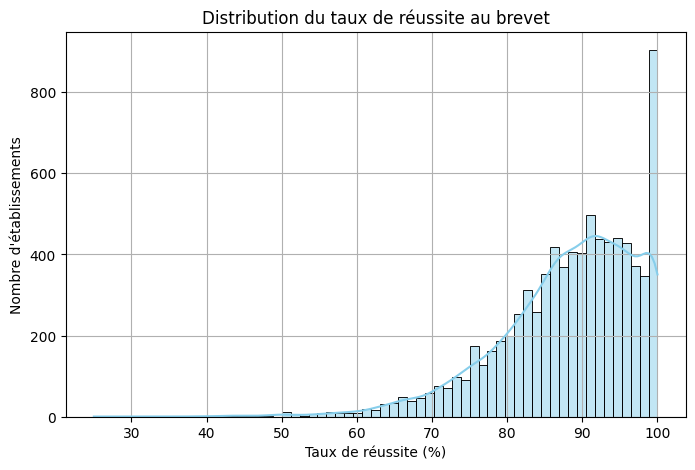

In [25]:
# Importation des bibliothèques pour la visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Graphique 1 : Distribution du taux de réussite au brevet
plt.figure(figsize=(8, 5))  # Taille de la figure
sns.histplot(df["Taux de réussite"], kde=True, color="skyblue")  # Histogramme avec courbe de densité
plt.title("Distribution du taux de réussite au brevet")  # Titre du graphique
plt.xlabel("Taux de réussite (%)")  # Nom de l’axe des abscisses
plt.ylabel("Nombre d'établissements")  # Nom de l’axe des ordonnées
plt.grid(True)  # Affichage d'une grille légère
plt.show()  # Affichage du graphique

# Aide de la documentation de Seaborn et matplotlib
# Aide de ChatGPT pour rendre le graphe plus lisible


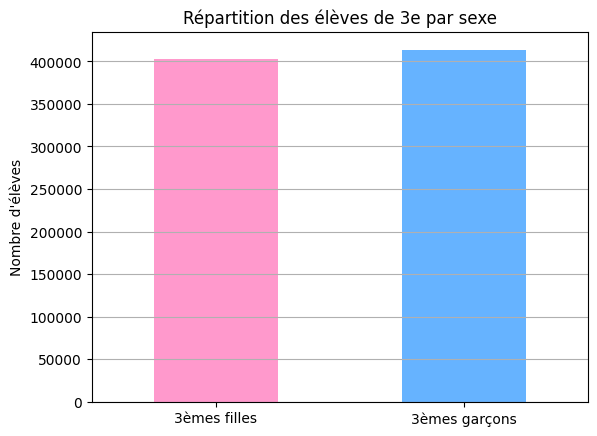

In [26]:
# Graphique 2 : Répartition des élèves de 3e par sexe
df_sexes = df[["3èmes filles", "3èmes garçons"]].sum()  # Somme totale des effectifs filles et garçons

# Création du graphique en barres avec pandas + matplotlib
df_sexes.plot(kind="bar", color=["#ff99cc", "#66b3ff"])
plt.title("Répartition des élèves de 3e par sexe")  # Titre du graphique
plt.ylabel("Nombre d'élèves")  # Nom de l’axe Y
plt.xticks(rotation=0)  # Nom de l'axe X
plt.grid(axis='y')  # Grille uniquement sur l’axe X
plt.show()  # Affichage du graphique

# Code basé sur la documentation pandas.plot et matplotlib.pyplot

Ce graphique montre la répartition du taux de réussite au brevet dans l’ensemble des établissements.
On observe une forte concentration entre 80 % et 100 %, avec un pic marqué à 100 %, ce qui signifie que beaucoup d’établissements obtiennent de très bons résultats.
À l’inverse, les taux inférieurs à 70 % sont très rares, ce qui indique que la plupart des collèges réussissent bien l’examen.
La courbe de densité confirme cette tendance avec une forme asymétrique.

Sur ce graphique, on peut observer que les garçons sont légèrement plus nombreux que les filles mais la répartition des sexes est quand même plutôt bien équilibré.

/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/2787633115.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="secteur_enseignement", y="Taux de réussite", data=df, palette="coolwarm")


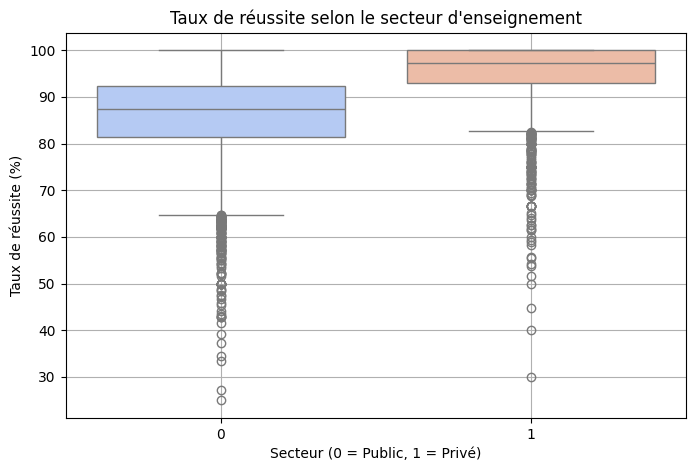

In [27]:
# Graphique 3 : Boxplot du taux de réussite en fonction du secteur d'enseignement
plt.figure(figsize=(8, 5))  # Définition de la taille du graphique
sns.boxplot(x="secteur_enseignement", y="Taux de réussite", data=df, palette="coolwarm")
plt.title("Taux de réussite selon le secteur d'enseignement")  # Titre du graphique
plt.xlabel("Secteur (0 = Public, 1 = Privé)")  # Légende axe X
plt.ylabel("Taux de réussite (%)")  # Légende axe Y
plt.grid(True)  # Affichage d’une grille
plt.show()  # Affichage du graphique

# Code inspiré de la documentation Seaborn


Ce graphique permet de comparer les résultats entre les établissements publics (0) et privés (1)
On observe que les établissements privés ont globalement de meilleurs taux de réussite et moins de variabilité.


/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/1157875370.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=moyennes.index, y=moyennes.values, palette="viridis")


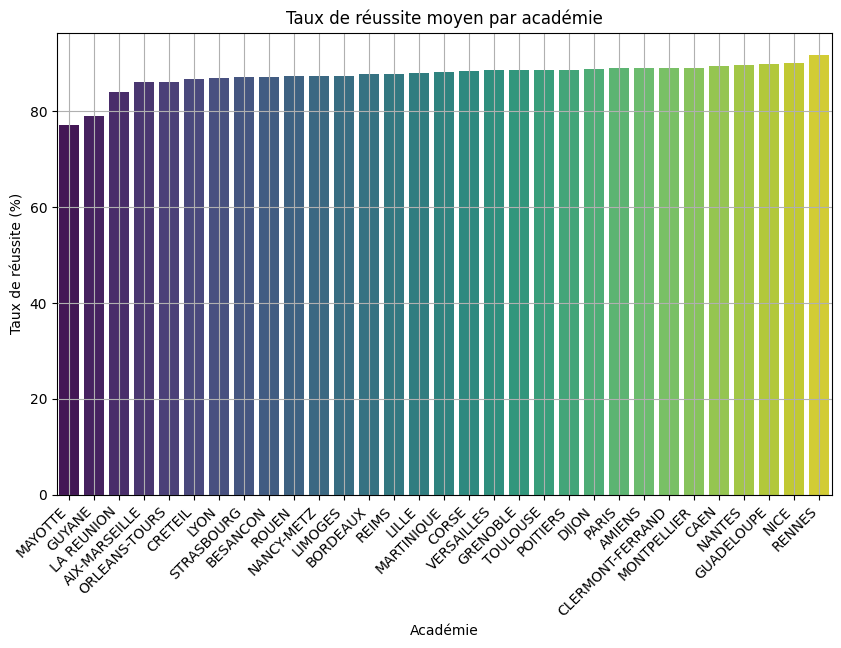

In [28]:
# Graphique 4 : Barplot du taux de réussite moyen par académie
plt.figure(figsize=(10, 6))  # Taille de la figure

# Calcul du taux moyen de réussite par académie
moyennes = df.groupby("academie")["Taux de réussite"].mean().sort_values()
# Création du barplot à partir des moyennes calculées
sns.barplot(x=moyennes.index, y=moyennes.values, palette="viridis")

plt.title("Taux de réussite moyen par académie")  # Titre du graphique
plt.xlabel("Académie")  # Nom de l’axe des X
plt.ylabel("Taux de réussite (%)")  # Nom de l’axe des Y
plt.xticks(rotation=45, ha='right')  # Rotation des étiquettes de l’axe X pour éviter le chevauchement des noms
plt.grid(True)  # Affichage d’une grille
plt.show()  # Affichage du graphique

# Aide de Chatgpt pour le choix des palettes et le tri avec sort_values()


Ce graphique permet de visualiser les différences de performance au brevet selon les académies.
On constate que certaines académies ont des taux de réussite beaucoup plus élevés que d'autres.


/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/2206444201.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Taille établissement", y="Taux de réussite", data=df, palette="Set3")


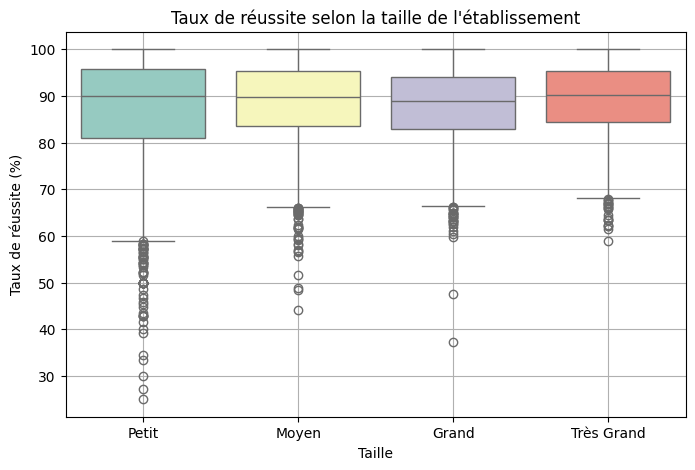

In [29]:
# Graphique 5 : Boxplot du taux de réussite selon la taille de l’établissement

# Création d'une nouvelle colonne 'Taille établissement' en divisant les effectifs en quartiles
# Utilisation de pd.qcut() pour segmenter automatiquement en 4 classes de taille
df["Taille établissement"] = pd.qcut(df["Nombre d'élèves total"], q=4, labels=["Petit", "Moyen", "Grand", "Très Grand"])
plt.figure(figsize=(8, 5))  # Taille de la figure
sns.boxplot(x="Taille établissement", y="Taux de réussite", data=df, palette="Set3")
plt.title("Taux de réussite selon la taille de l'établissement")  # Titre du graphique
plt.xlabel("Taille")  # Nom de l’axe X
plt.ylabel("Taux de réussite (%)")  # Nom de l’axe Y
plt.grid(True)  # Affichage d’une grille
plt.show()  # Affichage du graphique

# Aide de ChatGPT pour l'utilisation de qcut()



On divise les établissements en 4 groupes selon le nombre total d’élèves.
Le graphique montre que les établissements les plus grands ont en moyenne un meilleur taux de réussite.


/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/1751480597.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Langue Vivante", y="Taux de réussite", data=df_langues, palette="Set2")


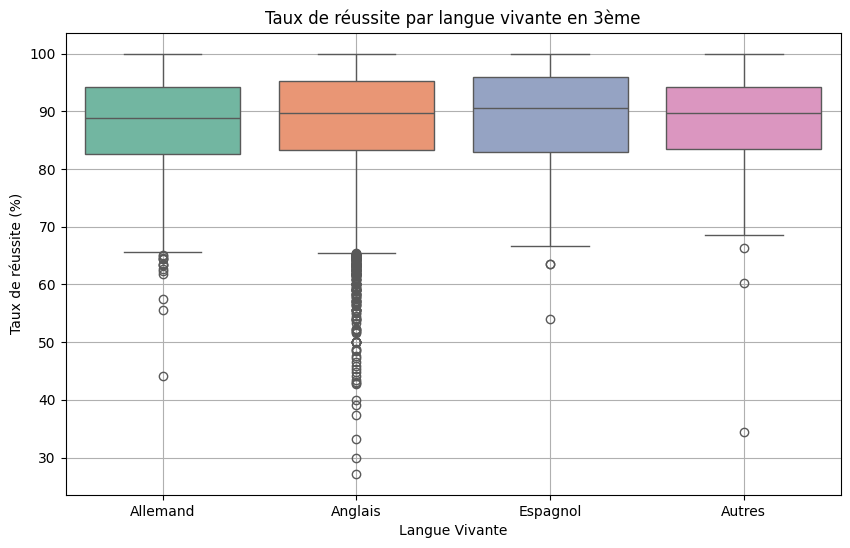

In [31]:
# Graphique 6 : Boxplot des taux de réussite selon la langue vivante étudiée en 3e
langues = ["3èmes LV1 allemand", "3èmes LV1 anglais", "3èmes LV1 espagnol", "3èmes LV1 autres langues"]

# Restructuration du DataFrame pour passer d’un format large à un format long (long format)
df_langues = df.melt(id_vars=["Taux de réussite"], value_vars=langues, var_name="Langue Vivante", value_name="Nombre d'élèves")

# Filtrage des lignes où aucun élève n'étudie la langue concernée
df_langues = df_langues[df_langues["Nombre d'élèves"] > 0]

# Remplacement des noms de colonnes
df_langues["Langue Vivante"] = df_langues["Langue Vivante"].replace({ "3èmes LV1 allemand": "Allemand", "3èmes LV1 anglais": "Anglais","3èmes LV1 espagnol": "Espagnol",
    "3èmes LV1 autres langues": "Autres"})

plt.figure(figsize=(10, 6))  # Taille du graphique
sns.boxplot(x="Langue Vivante", y="Taux de réussite", data=df_langues, palette="Set2")
plt.title("Taux de réussite par langue vivante en 3ème")  # Titre du graphique
plt.xlabel("Langue Vivante")  # Nom de l’axe X
plt.ylabel("Taux de réussite (%)")  # Nom de l’axe Y
plt.grid(True)  # Affichage d’une grille
plt.show()  # Affichage final

# Utilisation de la documentation de pandas.melt()



On transforme les colonnes de langue vivante pour les comparer directement
L’objectif est de voir s’il existe une différence de réussite selon la LV1 choisie


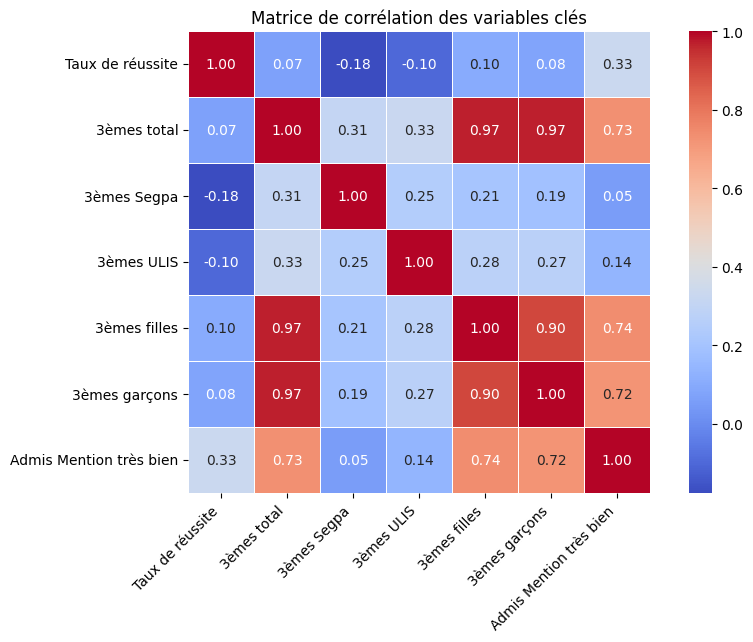

In [40]:
# Graphique 7 : Matrice de corrélation des variables clés
cols_corr = ["Taux de réussite", "3èmes total", "3èmes Segpa", "3èmes ULIS", "3èmes filles", "3èmes garçons", "Admis Mention très bien"]

# Calcul de la matrice de corrélation avec pandas.corr()
corr_matrix = df[cols_corr].corr()
plt.figure(figsize=(10, 6))  # Taille de la figure adaptée
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Matrice de corrélation des variables clés")  # Titre du graphique
plt.xticks(rotation=45, ha='right')  # Rotation des étiquettes en X
plt.yticks(rotation=0)  # Affichage horizontal sur Y
plt.show()  # Affichage du graphique

# Aide de ChatGPT pour la heatmap
# Aide de pandas pour la méthode de corr()



On remarque que le taux de réussite est lié au nombre d’élèves ayant obtenu une mention très bien,
et qu’il est un peu plus faible quand il y a plus d’élèves en SEGPA ou ULIS. Cela donne déjà une idée des variables qui influencent les résultats.


/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/3234697475.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Profil simplifié", y="Taux de réussite", data=df, palette="Set2")


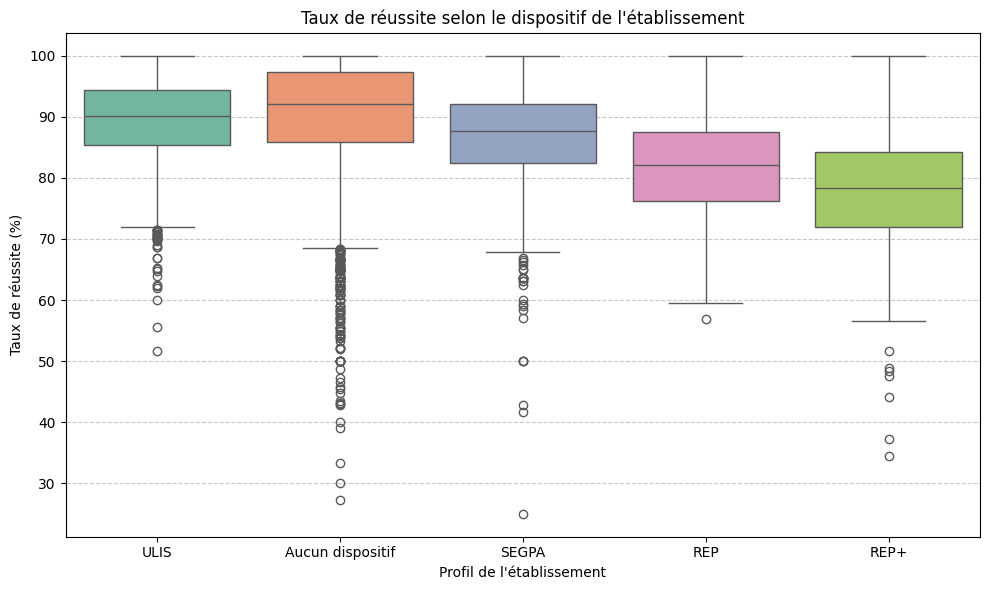

In [41]:
# Graphique 8 : Taux de réussite selon le dispositif de l'établissement

# Fonction de simplification du profil des établissements
def simplifier_profil(row):
    if row["REP +"] == 1:
        return "REP+"
    elif row["REP"] == 1:
        return "REP"
    elif row["Nombre d'élèves total Segpa"] > 0:
        return "SEGPA"
    elif row["Nombre d'élèves total ULIS"] > 0:
        return "ULIS"
    else:
        return "Aucun dispositif"

# Application de la fonction à chaque ligne du DataFrame
df["Profil simplifié"] = df.apply(simplifier_profil, axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(x="Profil simplifié", y="Taux de réussite", data=df, palette="Set2")
plt.title("Taux de réussite selon le dispositif de l'établissement")  # Titre
plt.xlabel("Profil de l'établissement")  # Nom de l'axe X
plt.ylabel("Taux de réussite (%)")  # Nom de l'axe Y
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Grille sur Y pour lisibilité
plt.tight_layout()  # Ajustement automatique des marges
plt.show()  # Affichage du graphique

# Aide de ChatGPT pour la structuration de la logique avec if/elif et l’utilisation de apply()


On remarque que les établissements sans dispositif ou avec ULIS ont les meilleurs taux. En revanche, ceux en REP ou REP+ ont des résultats globalement plus bas. Cela montre que le contexte social a un vrai impact sur les résultats au brevet.


## 3. Modèles de Machine Learning <a id="ml"></a>

### 3.1 Random Forest <a id="rf1"></a>


In [43]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Chargement des données préparées
df = pd.read_csv("merged_data.csv")

# Nettoyage : conversion du taux de réussite de type chaîne en float
# Utilisation de la documentation officielle de pandas
df["Taux de réussite"] = df["Taux de réussite"].astype(str).str.replace(",", ".").str.rstrip("%").astype(float)

# Sélection manuelle des colonnes numériques
num_cols = [
    "code_region_academique", "code_academie", "code_departement", "type_etablissement", "secteur_enseignement",
    "REP", "REP +", "Nombre d'élèves total", "Nombre d'élèves total Segpa", "Nombre d'élèves total ULIS", 
    "3èmes total", "3èmes hors Segpa hors ULIS", "3èmes Segpa", "3èmes ULIS", "3èmes filles", "3èmes garçons",
    "3èmes LV1 allemand", "3èmes LV1 anglais", "3èmes LV1 espagnol", "3èmes LV1 autres langues", 
    "Inscrits", "Presents", "Admis", "Admis sans mention", "Admis Mention AB", 
    "Admis Mention bien", "Admis Mention très bien"
]

# Utilisation de Stack Overflow) pour apply()
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Séparation des données 2019-2020 pour l'entraînement et 2021 pour le test
train_data = df[df["session"].isin([2019, 2020])]
test_data = df[df["session"] == 2021]

# Définition des variables explicatives (features) et de la variable cible (target)
features = num_cols
target = "Taux de réussite"

# Extraction des données X (features) et y (cible)
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Traitement des valeurs manquantes par imputation moyenne
# Utilisation de la documentation pandas et de Stack Overflow
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Initialisation du modèle Random Forest Regressor
# Utilisation de la documentation de sklearn et quelques tests manuels
model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# Prédiction sur l'année 2021
y_pred = model.predict(X_test)

# Évaluation du modèle avec deux métriques classiques
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Création du DataFrame de comparaison entre valeurs réelles et prédictions
prediction_results = pd.DataFrame({"Académie": test_data["academie"], "Taux de réussite réel": y_test, "Taux de réussite prédit": y_pred})

# Affichage des scores du modèle
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.2f}")

# Enregistrement des prédictions dans un fichier
prediction_results.to_csv("pred_2021_RF1.csv", index=False)
print("Les prédictions sont enregistrées")

/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/3280037508.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.fillna(X_train.mean(), inplace=True)
/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/3280037508.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.fillna(X_test.mean(), inplace=True)


Mean Absolute Error (MAE) : 2.54
Coefficient de détermination (R²) : 0.81
Les prédictions sont enregistrées


Le modèle Random Forest que nous avons entraîné permet de prédire le taux de réussite au brevet d’un établissement à partir de ses caractéristiques. Les résultats obtenus sont très satisfaisants :

MAE = 2.54 :
Cela signifie que l'erreur moyenne entre les taux de réussite prédits et les taux réels est d’environ 2,5 points de pourcentage. En pratique, c’est une erreur faible sur une échelle de 0 à 100 %, donc le modèle est précis.
R² = 0.81 :
Le coefficient de détermination R² indique que 81 % de la variabilité du taux de réussite est expliquée par les variables que nous avons utilisées. C’est un très bon score, qui montre que le modèle est performant et que les variables choisies sont pertinentes.

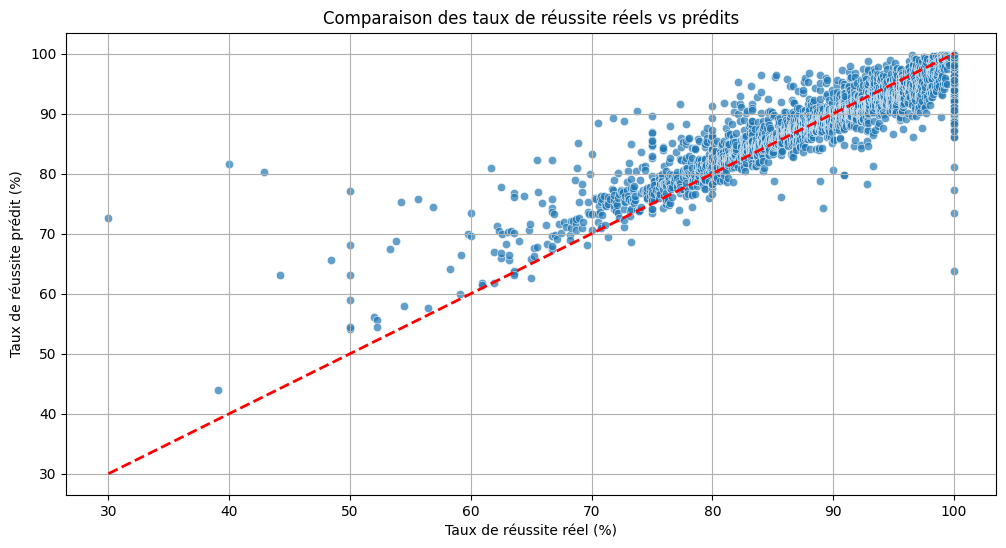

In [44]:
# Chargement du fichier des prédictions de Random Forest
df_predictions_2021 = pd.read_csv("pred_2021_RF1.csv")

# Tri des académies par taux de réussite réel pour un affichage plus lisible
df_predictions_2021 = df_predictions_2021.sort_values("Taux de réussite réel")

plt.figure(figsize=(12, 6))  # Taille de la figure
sns.scatterplot(x=df_predictions_2021["Taux de réussite réel"], y=df_predictions_2021["Taux de réussite prédit"], alpha=0.7)

plt.plot([df_predictions_2021["Taux de réussite réel"].min(), df_predictions_2021["Taux de réussite réel"].max()],
[df_predictions_2021["Taux de réussite réel"].min(), df_predictions_2021["Taux de réussite réel"].max()],
color='red', linestyle='dashed', linewidth=2)

plt.xlabel("Taux de réussite réel (%)")
plt.ylabel("Taux de réussite prédit (%)")
plt.title("Comparaison des taux de réussite réels vs prédits")
plt.grid(True) # Affichage d'une grille
plt.show() # Affichage du graphique

# Utilisation de la documentation seaborn et matplotlib


/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1171/1267911686.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Variable", data=importance_df, palette="viridis")


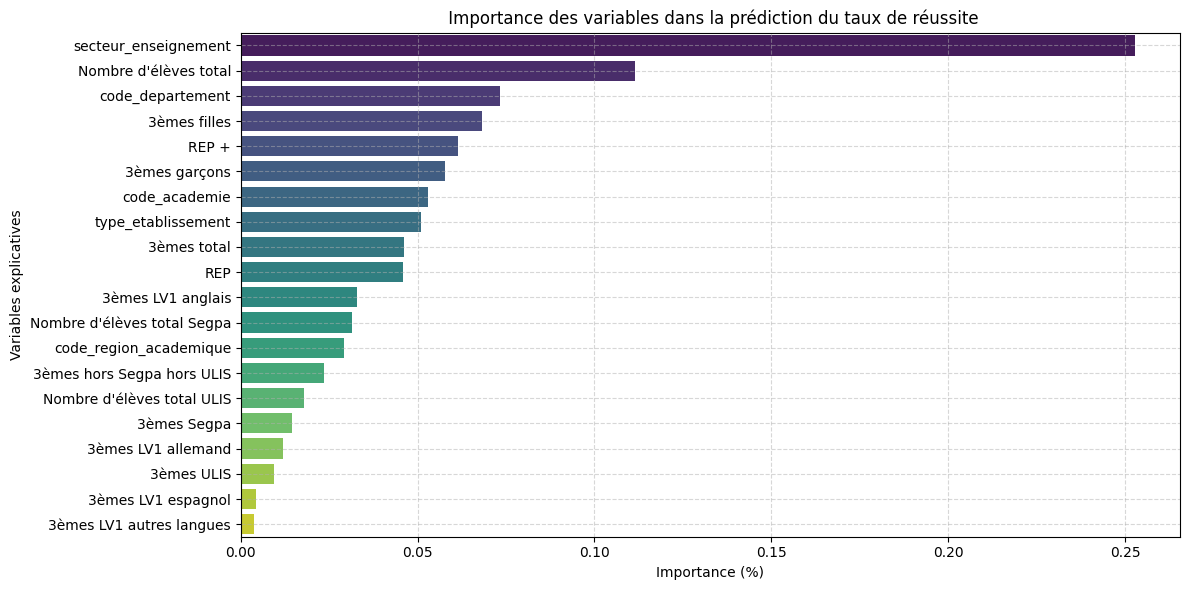

In [18]:
# Importance des variables selon le modèle Random Forest
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération des importances des variables à partir du modèle entraîné
feature_importance = model.feature_importances_

# Création d’un DataFrame pour stocker les noms des variables et leur importance
importance_df = pd.DataFrame({'Variable': features, 'Importance': feature_importance}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Variable", data=importance_df, palette="viridis")
plt.xlabel("Importance (%)")
plt.ylabel("Variables explicatives")
plt.title("Importance des variables dans la prédiction du taux de réussite")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Utilisation de la documentation scikit-learn et les exemples matplotlib/seaborn


### 3.2 Random Forest 2 <a id="rf2"></a>

In [46]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Chargement des données fusionnées
df = pd.read_csv("merged_data.csv")

# Nettoyage de la variable cible : conversion du taux de réussite en float
df["Taux de réussite"] = df["Taux de réussite"].astype(str).str.replace(",", ".").str.rstrip("%").astype(float)

# Sélection des colonnes numériques utilisées comme variables explicatives
num_cols = [
    "code_region_academique", "code_academie", "code_departement", "type_etablissement", "secteur_enseignement",
    "REP", "REP +", "Nombre d'élèves total", "Nombre d'élèves total Segpa", "Nombre d'élèves total ULIS", 
    "3èmes total", "3èmes hors Segpa hors ULIS", "3èmes Segpa", "3èmes ULIS", "3èmes filles", "3èmes garçons",
    "3èmes LV1 allemand", "3èmes LV1 anglais", "3èmes LV1 espagnol", "3èmes LV1 autres langues"
]

# Conversion explicite en numérique avec gestion des erreurs
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Séparation des données 2019-2020 pour l'entraînement et 2021 pour le test
train_data = df[df["session"].isin([2019, 2020])]
test_data = df[df["session"] == 2021]

# Définition des features et de la variable cible
features = num_cols
target = "Taux de réussite"

# Extraction des données d'entraînement et de test
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Imputation moyenne pour les valeurs manquantes
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Initialisation du modèle Random Forest Regressor
model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# Prédiction sur les données de test (établissements de l'année 2021)
y_pred = model.predict(X_test)

# Évaluation du modèle via deux métriques classiques
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Création d’un DataFrame pour comparer les valeurs réelles et les prédictions
prediction_results = pd.DataFrame({
    "Académie": test_data["academie"],
    "Taux de réussite réel": y_test,
    "Taux de réussite prédit": y_pred
})

# Affichage des scores pour analyse
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.2f}")

# Sauvegarde des résultats dans un fichier CSV
prediction_results.to_csv("pred_2021_RF2.csv", index=False)
print("Les prédictions sont enregistrées avec les nouvelles variables.")

# Utilisation de la documentaion pandas et des forums de Stack Overflow

/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/3619224169.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.fillna(X_train.mean(), inplace=True)
/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/3619224169.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.fillna(X_test.mean(), inplace=True)


Mean Absolute Error (MAE) : 5.79
Coefficient de détermination (R²) : 0.24
Les prédictions sont enregistrées avec les nouvelles variables.


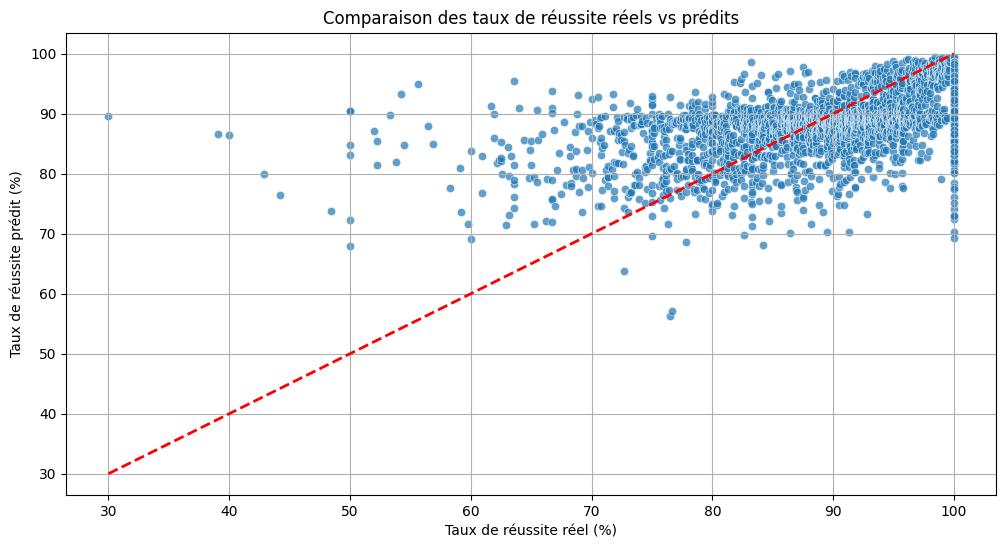

In [47]:
# Chargement des prédictions du modèle Random Forest sans variables biaisées
df_pred_2021_RF = pd.read_csv("pred_2021_RF2.csv")

# Tri des académies par taux de réussite réel
df_pred_2021_RF = df_pred_2021_RF.sort_values("Taux de réussite réel")
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_pred_2021_RF["Taux de réussite réel"], y=df_pred_2021_RF["Taux de réussite prédit"], alpha=0.7)

plt.plot([df_pred_2021_RF["Taux de réussite réel"].min(), df_pred_2021_RF["Taux de réussite réel"].max()],
[df_pred_2021_RF["Taux de réussite réel"].min(), df_pred_2021_RF["Taux de réussite réel"].max()],
color='red', linestyle='dashed', linewidth=2)
plt.xlabel("Taux de réussite réel (%)")
plt.ylabel("Taux de réussite prédit (%)")
plt.title("Comparaison des taux de réussite réels vs prédits")
plt.grid(True)
plt.show()


/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1171/340029330.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Variable", data=importance_df, palette="viridis")


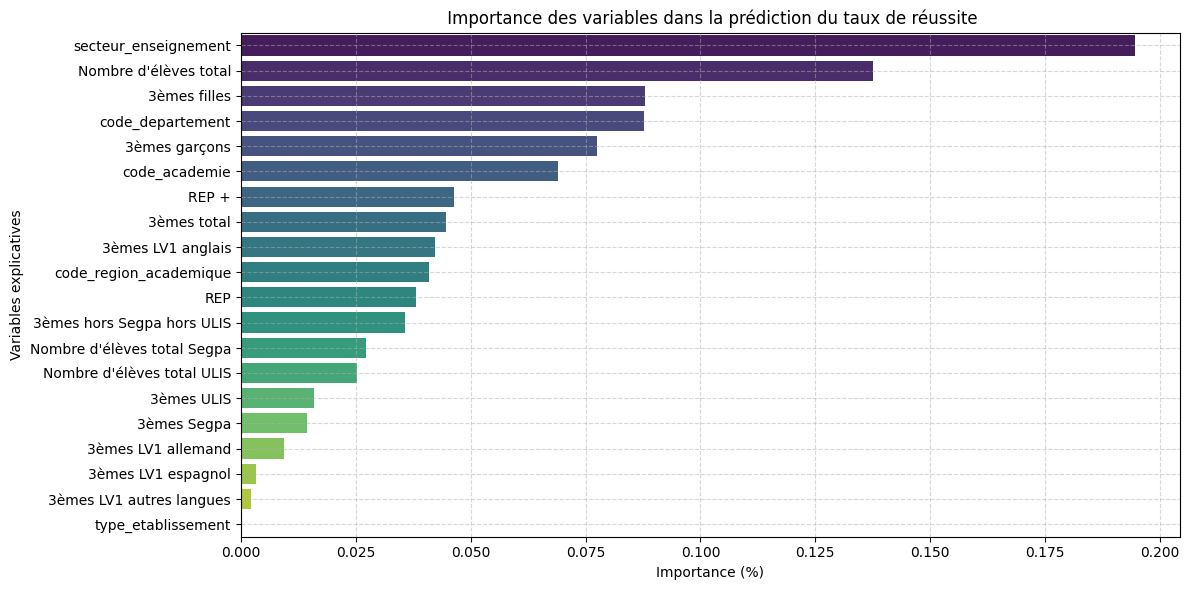

In [22]:
# Importance des variables selon le modèle Random Forest
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération de l'importance des variables
feature_importance = model.feature_importances_

# Création d'un DataFrame pour visualiser les résultats
importance_df = pd.DataFrame({
    'Variable': features,
    'Importance': feature_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Variable", data=importance_df, palette="viridis")
plt.xlabel("Importance (%)")
plt.ylabel("Variables explicatives")
plt.title(" Importance des variables dans la prédiction du taux de réussite")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 3.3 Gradient Boosting <a id="gb"></a>

In [48]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Chargement des données fusionnées
df = pd.read_csv("merged_data.csv", low_memory=False)

# Nettoyage de la variable cible : conversion en float
# Remplacement de la virgule par un point et suppression du %
df["Taux de réussite"] = df["Taux de réussite"].astype(str).str.replace(",", ".").str.rstrip("%").astype(float)

# Encodage de la variable type_etablissement avec LabelEncoder
le = LabelEncoder()
df["type_etablissement"] = le.fit_transform(df["type_etablissement"].astype(str))

# Définition des variables explicatives (features) et de la cible (target)
features = ["code_region_academique", "code_academie", "code_departement", "type_etablissement", "secteur_enseignement",
    "REP", "REP +", "Nombre d'élèves total", "Nombre d'élèves total Segpa", "Nombre d'élèves total ULIS",
    "3èmes total", "3èmes hors Segpa hors ULIS", "3èmes Segpa", "3èmes ULIS", "3èmes filles", "3èmes garçons",
    "3èmes LV1 allemand", "3èmes LV1 anglais", "3èmes LV1 espagnol", "3èmes LV1 autres langues"]
target = "Taux de réussite"

# Conversion de toutes les features en numérique
# Méthode recommandée par Chatgpt
df[features] = df[features].apply(pd.to_numeric, errors='coerce')

# Séparation des données en jeu d'entraînement des années 2019-2020 et jeu de test 2021
train_data = df[df["session"].isin([2019, 2020])].copy()
test_data = df[df["session"] == 2021].copy()

# Création des matrices d'entraînement et de test
X_train = train_data[features].copy()
y_train = train_data[target].copy()
X_test = test_data[features].copy()
y_test = test_data[target].copy()

# Imputation des valeurs manquantes par la moyenne calculée sur le jeu d'entraînement
# Cette technique évite les biais liés aux données de test
means = X_train.mean()
X_train = X_train.fillna(means)
X_test = X_test.fillna(means)

# Vérification finale pour s'assurer qu'il ne reste aucune valeur manquante
assert not X_train.isnull().values.any()
assert not X_test.isnull().values.any()

# Initialisation du modèle Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# Prédictions sur le jeu de test
y_pred = model.predict(X_test)

# Évaluation du modèle
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.2f}")

# Création du DataFrame contenant les prédictions et les valeurs réelles
prediction_results = pd.DataFrame({"Académie": test_data["academie"], "Taux de réussite réel": y_test, "Taux de réussite prédit": y_pred})

# Enregistrement des résultats dans un fichier CSV
prediction_results.to_csv("pred_2021_GB.csv", index=False)
print("📁 Prédictions enregistrées dans 'pred_2021_GB.csv'")



Mean Absolute Error (MAE) : 5.80
Coefficient de détermination (R²) : 0.23
📁 Prédictions enregistrées dans 'pred_2021_GB.csv'


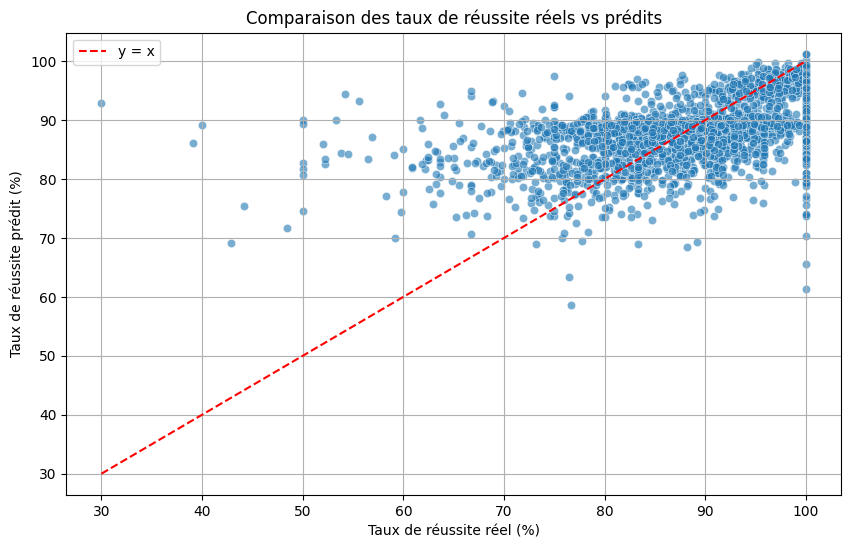

/var/folders/2n/kv1g4t4d4n7g9kx4nhznvm_h0000gn/T/ipykernel_1659/1927268098.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Variable", data=importance_df.head(20), palette="viridis")


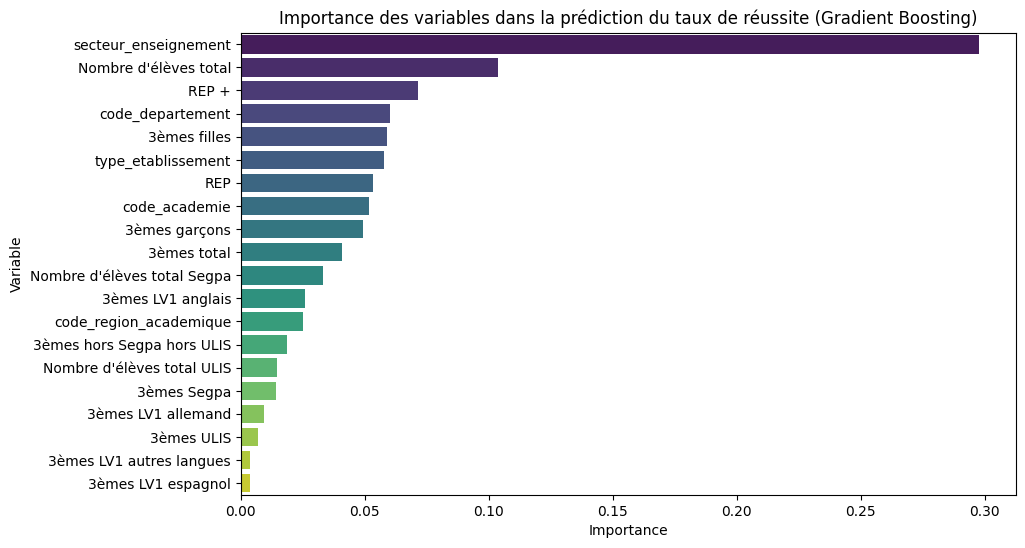

In [50]:
# Comparaison entre les taux réels et les taux prédits
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Taux de réussite réel (%)")
plt.ylabel("Taux de réussite prédit (%)")
plt.title("Comparaison des taux de réussite réels vs prédits")
plt.legend()
plt.grid(True)
plt.show()

# Utilisation de la documentation matplotlib et seaborn

# Importance des variables
# Récupération de l’importance des variables
feature_importances = model.feature_importances_

# Création d’un DataFrame trié par importance décroissante
importance_df = pd.DataFrame({"Variable": features, "Importance": feature_importances}).sort_values(by="Importance", ascending=False)

# Affichage des 20 variables les plus importantes
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=importance_df.head(20), palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables dans la prédiction du taux de réussite (Gradient Boosting)")
plt.show()

# Documentation utilisée : scikit-learn et Seaborn

In [52]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Chargement des données nettoyées fusionnées
df = pd.read_csv("merged_data.csv")

# Nettoyage de la cible : conversion du pourcentage de string à float
df["Taux de réussite"] = df["Taux de réussite"].astype(str).str.replace(",", ".").str.rstrip("%").astype(float)

# Encodage de la variable catégorielle type_etablissement avec LabelEncoder
le = LabelEncoder()
df["type_etablissement"] = le.fit_transform(df["type_etablissement"].astype(str))

# Définition des variables explicatives (features) et de la variable cible
features = ["code_region_academique", "code_academie", "code_departement", "type_etablissement", "secteur_enseignement",
    "REP", "REP +", "Nombre d'élèves total", "Nombre d'élèves total Segpa", "Nombre d'élèves total ULIS",
    "3èmes total", "3èmes hors Segpa hors ULIS", "3èmes Segpa", "3èmes ULIS", "3èmes filles", "3èmes garçons",
    "3èmes LV1 allemand", "3èmes LV1 anglais", "3èmes LV1 espagnol", "3èmes LV1 autres langues"]
target = "Taux de réussite"

# Conversion explicite en numérique avec gestion d'erreurs 
# Aide de chatgpt
df[features] = df[features].apply(pd.to_numeric, errors='coerce')

# Séparation en données d'entraînement et de test
train_data = df[df["session"].isin([2019, 2020])].copy()
test_data = df[df["session"] == 2021].copy()

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Imputation des valeurs manquantes par la moyenne du jeu d'entraînement
means = X_train.mean()
X_train = X_train.fillna(means)
X_test = X_test.fillna(means)

# Entraînement du modèle Gradient Boosting avec hyperparamètres personnalisés
model = GradientBoostingRegressor(learning_rate=0.1, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100,
    subsample=1.0, random_state=42)

# Apprentissage sur les données d'entraînement
model.fit(X_train, y_train)

# Prédictions sur les établissements de l'année 2021
y_pred = model.predict(X_test)

# Évaluation du modèle avec deux métriques classiques :
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.2f}")

# Création d’un DataFrame pour comparer les prédictions et les valeurs observées
prediction_results = pd.DataFrame({"Académie": test_data["academie"], "Taux de réussite réel": y_test,
    "Taux de réussite prédit": y_pred})

# Sauvegarde des résultats dans un fichier CSV
prediction_results.to_csv("pred_2021_GB2.csv", index=False)
print("Les prédictions sont enregistrées dans 'pred_2021_GB2.csv'")


Mean Absolute Error (MAE) : 5.71
Coefficient de détermination (R²) : 0.25
Les prédictions sont enregistrées dans 'pred_2021_GB2.csv'
